In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [20]:
!pip install torchinfo

Import Libraries

In [21]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import OrderedDict
import platform
import psutil
import random
import glob
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ColorJitter, RandomRotation, RandomResizedCrop
from torchvision.transforms.functional import gaussian_blur
from PIL import ImageOps
from tabulate import tabulate

Configuration

In [22]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: No GPU available


Seed Value

In [23]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Loading Dataset

In [24]:
data_dir = "/kaggle/input/melanoma/test"

file_paths = []
labels = []

for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name)
    for image_name in os.listdir(class_dir):
        file_paths.append(os.path.join(class_dir, image_name))
        labels.append(class_name)

df = pd.DataFrame({"file_path": file_paths, "label": labels})
df = df.sample(frac=1).reset_index(drop=True)

Class: Benign, Count: 1000
Class: Malignant, Count: 1000


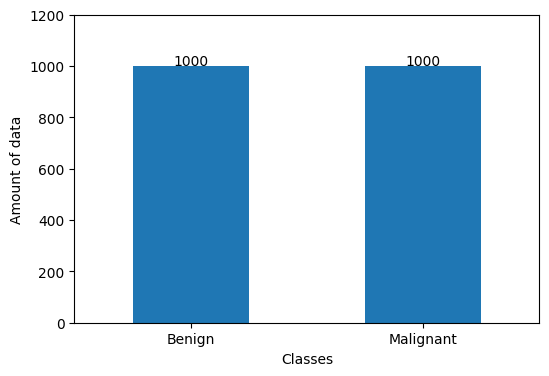

In [6]:
class_counts_train = df['label'].value_counts()

for class_name, count in class_counts_train.items():
    print(f"Class: {class_name}, Count: {count}")

plt.figure(figsize=(6, 4))
ax = class_counts_train.plot(kind='bar')
plt.xlabel('Classes')
plt.ylabel('Amount of data')
plt.xticks(rotation=360)
for i, count in enumerate(class_counts_train):
    ax.text(i, count + 5, str(count), ha='center')
plt.ylim(0, max(class_counts_train) * 1.2)
plt.show()

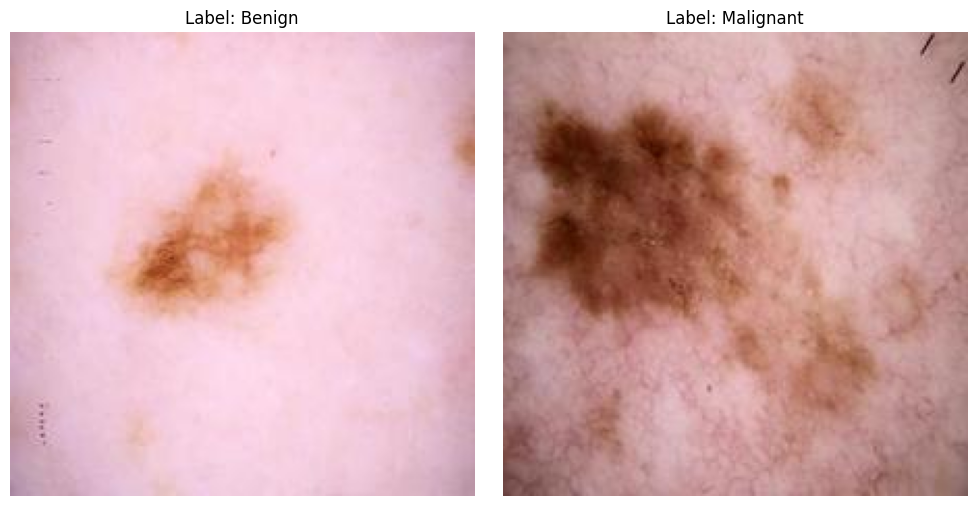

In [25]:
import random
from PIL import Image
import matplotlib.pyplot as plt

classes = df['label'].unique()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for idx, class_label in enumerate(classes):

    class_df = df[df['label'] == class_label]

    random_index = random.randint(0, len(class_df) - 1)
    random_row = class_df.iloc[random_index]

    file_path = random_row['file_path']
    label = random_row['label']

    image = Image.open(file_path)
    axes[idx].imshow(image)
    axes[idx].set_title(f"Label: {label}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


Train-Test-Validation Split (Ratio 70:15:15)

In [26]:
from sklearn.model_selection import train_test_split


rest_dataframe, test_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

print("Remaining Data (for training/validation):", len(rest_dataframe))
print("Test Data:", len(test_df))
print("-------------------------------------------")
print("Total data in dataset:", len(df))


Remaining Data (for training/validation): 1400
Test Data: 600
-------------------------------------------
Total data in dataset: 2000


In [27]:
print("Test Data: ", len(test_df))
print("-------------------------------------------")
print("Total amounts of data in the dataset: ", len(df))


Test Data:  600
-------------------------------------------
Total amounts of data in the dataset:  2000


In [28]:
from tabulate import tabulate
class_counts_test = test_df['label'].value_counts()
test_table_data = [[class_name, count] for class_name, count in class_counts_test.items()]

print("Test Dataset")
print(tabulate(test_table_data, headers=["Class", "Count"]))


Test Dataset
Class        Count
---------  -------
Benign         300
Malignant      300


Device Variable

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Checkpoint


In [30]:
save_path_checkpoints = "/kaggle/working/"
os.makedirs(save_path_checkpoints, exist_ok=True)


Dataset Class, Dataloader and Transform

In [31]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=False):
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        self.label_map = {'Benign': 0, 'Malignant': 1}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = PIL.Image.open(img_path)

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

In [32]:
from torch.utils.data import DataLoader
from torchvision import transforms

test_batch = 8  

def data_transform_test_only():
    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    test_dataset = ImageDataset(
        test_df,
        normalize,
        is_lb=True
    )

    dataloader_test_dataset = DataLoader(
        test_dataset, 
        batch_size=test_batch, 
        shuffle=False, 
        num_workers=2
    )

    return dataloader_test_dataset

dataloader_test_dataset = data_transform_test_only()


Neural Network (ResNet)

In [34]:
total_class = 2
learning_rate = 0.0001

model = models.resnet50(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, total_class)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
summary(model, input_size=(test_batch, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 2]                    --
├─Conv2d: 1-1                            [8, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         128
├─ReLU: 1-3                              [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [8, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [8, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [8, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [8, 64, 56, 56]           --
│ 

In [36]:
# ------------------ TEST EVALUATION ------------------

model.eval()
correct_test = 0
total_test = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in dataloader_test_dataset:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        test_loss += loss.item() * inputs.size(0)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

avg_test_loss = test_loss / total_test
test_accuracy = correct_test / total_test

print(f"\nTest Loss: {avg_test_loss:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Optionally, add to Excel sheet
test_summary = pd.DataFrame({
    "Metric": ["Test Loss", "Test Accuracy"],
    "Value": [avg_test_loss, test_accuracy]
})

# Save both training history and test results
with pd.ExcelWriter('/kaggle/working/training_data_with_test.xlsx') as writer:
    history.to_excel(writer, index=False, sheet_name='Train_Val_History')
    test_summary.to_excel(writer, index=False, sheet_name='Test_Summary')



Test Loss: 0.673
Test Accuracy: 0.572


IndexError: At least one sheet must be visible

In [ ]:
history = pd.read_excel('/kaggle/working/training_data.xlsx')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
plt.plot(history['Validation Loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.ylim(0,2)

plt.subplot(1, 2, 2)
plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
plt.plot(history['Validation Accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='lower right')
plt.ylim(0,1.1)

plt.show()

Evaluation

In [ ]:
def evaluate_model(model, criterion, dataloader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [ ]:
best_checkpoint_path = f"{save_path_checkpoints}/model.pt"
checkpoint = torch.load(best_checkpoint_path)
best_epoch = checkpoint["epoch"]
model.load_state_dict(checkpoint["model_weight"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")

In [ ]:
def class_accuracy(model, dataloader, num_classes):
    class_correct = [0.0] * num_classes
    class_total = [0.0] * num_classes

    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct = (predicted == labels)
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct[i].item()
                class_total[label] += 1

    class_accuracy = [class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(num_classes)]

    return class_accuracy

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloader_test_dataset:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = [str(i) for i in range(total_class)]

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

class_acc = class_accuracy(model, dataloader_test_dataset, total_class)
for i in range(total_class):
    print(f"Class {i} Accuracy: {class_acc[i]:.3f}")